# **Building LLM from sratch**

In [20]:
import math
import time
import tiktoken
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available()
    else "cpu"
)

device


'cuda'

**Dataset,DataLoader**

In [21]:
class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

        for i in range(0, len(token_ids) - max_length, stride):
            inp = token_ids[i:i+max_length]
            tgt = token_ids[i+1:i+max_length+1]
            self.input_ids.append(torch.tensor(inp, dtype=torch.long))
            self.target_ids.append(torch.tensor(tgt, dtype=torch.long))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]



def create_dataloader_v1(txt, batch_size=8, max_length=256, stride=128):
    tokenizer = tiktoken.get_encoding("gpt2")
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    return loader, tokenizer


# **Model architecture ---> Multi-Attention mechanism , LayerNorm, Feed-forward network**

**MultiHeadAttention block**

In [22]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_q = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_k = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_v = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)

        mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)
        self.register_buffer("mask", mask)

    def forward(self, x):
        B, T, _ = x.shape

        q = self.W_q(x)
        k = self.W_k(x)
        v = self.W_v(x)

        q = q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        att = q @ k.transpose(-2, -1)
        att = att / math.sqrt(self.head_dim)

        mask = self.mask[:T, :T].bool()
        att.masked_fill_(mask, -1e10)

        att = torch.softmax(att, dim=-1)
        att = self.dropout(att)

        out = att @ v
        out = out.transpose(1, 2).contiguous().view(B, T, self.d_out)
        return self.out_proj(out)


class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))
        self.eps = 1e-5

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm + self.shift


class GELU(nn.Module):
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2/math.pi, device=x.device)) *
            (x + 0.044715 * x.pow(3))
        ))


class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        D = cfg["emb_dim"]
        self.layers = nn.Sequential(
            nn.Linear(D, 4*D),
            GELU(),
            nn.Linear(4*D, D)
        )

    def forward(self, x):
        return self.layers(x)


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            dropout=cfg["drop_rate"],
            num_heads=cfg["n_heads"],
            qkv_bias=cfg["qkv_bias"]
        )
        self.ff = FeedForward(cfg)
        self.ln1 = LayerNorm(cfg["emb_dim"])
        self.ln2 = LayerNorm(cfg["emb_dim"])
        self.dropout = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        x = x + self.dropout(self.att(self.ln1(x)))
        x = x + self.dropout(self.ff(self.ln2(x)))
        return x


class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop = nn.Dropout(cfg["drop_rate"])

        self.blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        self.ln_f = LayerNorm(cfg["emb_dim"])
        self.head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, idx):
        B, T = idx.shape
        tok = self.tok_emb(idx)
        pos = self.pos_emb(torch.arange(T, device=idx.device))[None, :, :]
        x = self.drop(tok + pos)
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.head(x)
        return logits


**Text generation helper**

In [23]:
@torch.no_grad()
def generate_text(model, idx, max_new_tokens, context_size, temperature=1.0, top_k=50):
    model.eval()

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        logits = model(idx_cond)           # (B, T, V)
        logits = logits[:, -1, :]          # (B, V)

        # temperature
        logits = logits / temperature

        # top-k filtering
        if top_k is not None:
            values, _ = torch.topk(logits, top_k)
            min_vals = values[:, -1].unsqueeze(-1)
            logits[logits < min_vals] = -1e10

        probs = torch.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)  # (B, 1)

        idx = torch.cat([idx, next_id], dim=1)

    return idx


**Training Loop**

In [24]:
def train_gpt(txt_path="input.txt", epochs=40, batch_size=8, lr=3e-4,
              max_length=128, stride=128, n_layers=3):

    import math
    import time

    start_time = time.time()

    # Load dataset
    with open(txt_path, "r", encoding="utf-8") as f:
        txt = f.read()
    txt = txt[:50000]

    loader, tokenizer = create_dataloader_v1(txt, batch_size, max_length, stride)

    # Config
    cfg = {
        "vocab_size": tokenizer.n_vocab,
        "context_length": max_length,
        "emb_dim": 192,
        "n_heads": 3,
        "n_layers": n_layers,   # ✅ dynamic
        "drop_rate": 0.1,
        "qkv_bias": False,
    }

    # Model
    model = GPTModel(cfg).to(device)
    optim = torch.optim.AdamW(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    # Training
    for ep in range(1, epochs+1):
        model.train()
        total = 0

        for inp, tgt in loader:
            inp, tgt = inp.to(device), tgt.to(device)

            logits = model(inp)
            B, T, V = logits.shape

            loss = loss_fn(
                logits.view(B*T, V),
                tgt.view(B*T)
            )

            optim.zero_grad()
            loss.backward()
            optim.step()

            total += loss.item()

        avg_loss = total / len(loader)
        print(f"Epoch {ep} Loss: {avg_loss:.4f}")

    # Final metrics
    end_time = time.time()
    training_time = end_time - start_time
    perplexity = math.exp(avg_loss)

    print(f"Total Training Time: {training_time:.2f} seconds")
    print(f"Perplexity: {perplexity:.2f}")

    return model, tokenizer, avg_loss, perplexity, training_time

In [25]:
!wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt

--2026-03-30 11:37:02--  https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt.2’

input.txt.2         100%[===================>]   1.06M  --.-KB/s    in 0.03s   

2026-03-30 11:37:02 (38.4 MB/s) - ‘input.txt.2’ saved [1115394/1115394]



**Train + Generate**

In [28]:
# =======================
# 🔹 TRAIN (OPTIMIZED MODEL)
# =======================

model, tokenizer, loss, perplexity, train_time = train_gpt(
    "input.txt",
    epochs=40,
    n_layers=4   # best config based on experiments
)

print("\n=== TRAINING RESULTS ===")
print(f"Final Loss: {loss:.4f}")
print(f"Perplexity: {perplexity:.2f}")
print(f"Training Time: {train_time:.2f} sec")


# =======================
# 🔹 TEXT GENERATION TEST
# =======================

start = "Mr. Dursley was the director"
encoded = tokenizer.encode(start)
idx = torch.tensor(encoded, device=device).unsqueeze(0)

model.eval()

with torch.no_grad():
    out = generate_text(
        model,
        idx,
        max_new_tokens=100,   # 🔥 increased for better evaluation
        context_size=128,
        temperature=0.6,
        top_k=40
    )

generated_text = tokenizer.decode(out[0].tolist())

print("\n=== GENERATED TEXT ===")
print(generated_text)

Epoch 1 Loss: 10.2151
Epoch 2 Loss: 8.6707
Epoch 3 Loss: 7.5358
Epoch 4 Loss: 6.6897
Epoch 5 Loss: 6.1886
Epoch 6 Loss: 5.9347
Epoch 7 Loss: 5.7806
Epoch 8 Loss: 5.6805
Epoch 9 Loss: 5.5332
Epoch 10 Loss: 5.4232
Epoch 11 Loss: 5.3001
Epoch 12 Loss: 5.1697
Epoch 13 Loss: 5.0627
Epoch 14 Loss: 4.9284
Epoch 15 Loss: 4.8249
Epoch 16 Loss: 4.7341
Epoch 17 Loss: 4.6359
Epoch 18 Loss: 4.5139
Epoch 19 Loss: 4.4115
Epoch 20 Loss: 4.3172
Epoch 21 Loss: 4.1884
Epoch 22 Loss: 4.0963
Epoch 23 Loss: 3.9904
Epoch 24 Loss: 3.8843
Epoch 25 Loss: 3.7888
Epoch 26 Loss: 3.6852
Epoch 27 Loss: 3.5810
Epoch 28 Loss: 3.4801
Epoch 29 Loss: 3.3733
Epoch 30 Loss: 3.2826
Epoch 31 Loss: 3.1764
Epoch 32 Loss: 3.1134
Epoch 33 Loss: 2.9906
Epoch 34 Loss: 2.8891
Epoch 35 Loss: 2.8016
Epoch 36 Loss: 2.6967
Epoch 37 Loss: 2.6133
Epoch 38 Loss: 2.5126
Epoch 39 Loss: 2.4340
Epoch 40 Loss: 2.3176
Total Training Time: 24.67 seconds
Perplexity: 10.15

=== TRAINING RESULTS ===
Final Loss: 2.3176
Perplexity: 10.15
Training Tim

In [29]:
model2, tokenizer2, loss2, perp2, time2 = train_gpt("input.txt", epochs=40, n_layers=2)

Epoch 1 Loss: 10.5461
Epoch 2 Loss: 9.0201
Epoch 3 Loss: 7.7519
Epoch 4 Loss: 6.8734
Epoch 5 Loss: 6.3311
Epoch 6 Loss: 6.0453
Epoch 7 Loss: 5.8872
Epoch 8 Loss: 5.7812
Epoch 9 Loss: 5.6928
Epoch 10 Loss: 5.6062
Epoch 11 Loss: 5.5254
Epoch 12 Loss: 5.4150
Epoch 13 Loss: 5.3168
Epoch 14 Loss: 5.1813
Epoch 15 Loss: 5.0848
Epoch 16 Loss: 4.9921
Epoch 17 Loss: 4.8796
Epoch 18 Loss: 4.7819
Epoch 19 Loss: 4.7472
Epoch 20 Loss: 4.6211
Epoch 21 Loss: 4.5337
Epoch 22 Loss: 4.4499
Epoch 23 Loss: 4.3620
Epoch 24 Loss: 4.2472
Epoch 25 Loss: 4.1710
Epoch 26 Loss: 4.0829
Epoch 27 Loss: 3.9918
Epoch 28 Loss: 3.8996
Epoch 29 Loss: 3.8250
Epoch 30 Loss: 3.7250
Epoch 31 Loss: 3.6420
Epoch 32 Loss: 3.5615
Epoch 33 Loss: 3.4883
Epoch 34 Loss: 3.4164
Epoch 35 Loss: 3.3190
Epoch 36 Loss: 3.2282
Epoch 37 Loss: 3.1565
Epoch 38 Loss: 3.0649
Epoch 39 Loss: 2.9863
Epoch 40 Loss: 2.9157
Total Training Time: 20.23 seconds
Perplexity: 18.46


In [30]:
model3, tokenizer3, loss3, perp3, time3 = train_gpt("input.txt", epochs=40, n_layers=3)

Epoch 1 Loss: 10.3119
Epoch 2 Loss: 8.7145
Epoch 3 Loss: 7.6039
Epoch 4 Loss: 6.8093
Epoch 5 Loss: 6.2943
Epoch 6 Loss: 6.0260
Epoch 7 Loss: 5.8562
Epoch 8 Loss: 5.7180
Epoch 9 Loss: 5.6122
Epoch 10 Loss: 5.5055
Epoch 11 Loss: 5.3997
Epoch 12 Loss: 5.2739
Epoch 13 Loss: 5.1498
Epoch 14 Loss: 5.0246
Epoch 15 Loss: 4.9313
Epoch 16 Loss: 4.8456
Epoch 17 Loss: 4.7200
Epoch 18 Loss: 4.6044
Epoch 19 Loss: 4.5108
Epoch 20 Loss: 4.4185
Epoch 21 Loss: 4.3130
Epoch 22 Loss: 4.2193
Epoch 23 Loss: 4.1266
Epoch 24 Loss: 4.0137
Epoch 25 Loss: 3.9248
Epoch 26 Loss: 3.8023
Epoch 27 Loss: 3.7347
Epoch 28 Loss: 3.6138
Epoch 29 Loss: 3.5428
Epoch 30 Loss: 3.4441
Epoch 31 Loss: 3.3451
Epoch 32 Loss: 3.2599
Epoch 33 Loss: 3.1749
Epoch 34 Loss: 3.0691
Epoch 35 Loss: 2.9908
Epoch 36 Loss: 2.9037
Epoch 37 Loss: 2.8236
Epoch 38 Loss: 2.7273
Epoch 39 Loss: 2.6343
Epoch 40 Loss: 2.5493
Total Training Time: 22.78 seconds
Perplexity: 12.80


In [31]:
model4, tokenizer4, loss4, perp4, time4 = train_gpt("input.txt", epochs=40, n_layers=4)

Epoch 1 Loss: 10.2386
Epoch 2 Loss: 8.7310
Epoch 3 Loss: 7.6084
Epoch 4 Loss: 6.7689
Epoch 5 Loss: 6.2572
Epoch 6 Loss: 5.9609
Epoch 7 Loss: 5.7913
Epoch 8 Loss: 5.6607
Epoch 9 Loss: 5.5414
Epoch 10 Loss: 5.4160
Epoch 11 Loss: 5.3007
Epoch 12 Loss: 5.1939
Epoch 13 Loss: 5.0653
Epoch 14 Loss: 4.9803
Epoch 15 Loss: 4.8306
Epoch 16 Loss: 4.7190
Epoch 17 Loss: 4.6276
Epoch 18 Loss: 4.5289
Epoch 19 Loss: 4.4210
Epoch 20 Loss: 4.3158
Epoch 21 Loss: 4.2088
Epoch 22 Loss: 4.0914
Epoch 23 Loss: 3.9798
Epoch 24 Loss: 3.8805
Epoch 25 Loss: 3.7796
Epoch 26 Loss: 3.6658
Epoch 27 Loss: 3.5826
Epoch 28 Loss: 3.4776
Epoch 29 Loss: 3.3701
Epoch 30 Loss: 3.2670
Epoch 31 Loss: 3.1772
Epoch 32 Loss: 3.0742
Epoch 33 Loss: 2.9645
Epoch 34 Loss: 2.8832
Epoch 35 Loss: 2.7803
Epoch 36 Loss: 2.6758
Epoch 37 Loss: 2.5801
Epoch 38 Loss: 2.4901
Epoch 39 Loss: 2.4008
Epoch 40 Loss: 2.2998
Total Training Time: 23.72 seconds
Perplexity: 9.97


In [35]:
model5, tokenizer5, loss5, perp5, time5 = train_gpt("input.txt", epochs=40, n_layers=5)

Epoch 1 Loss: 10.0936
Epoch 2 Loss: 8.5947
Epoch 3 Loss: 7.4605
Epoch 4 Loss: 6.6224
Epoch 5 Loss: 6.1522
Epoch 6 Loss: 5.8853
Epoch 7 Loss: 5.7418
Epoch 8 Loss: 5.6177
Epoch 9 Loss: 5.4964
Epoch 10 Loss: 5.3755
Epoch 11 Loss: 5.2426
Epoch 12 Loss: 5.1412
Epoch 13 Loss: 4.9827
Epoch 14 Loss: 4.8901
Epoch 15 Loss: 4.7705
Epoch 16 Loss: 4.6504
Epoch 17 Loss: 4.5187
Epoch 18 Loss: 4.4005
Epoch 19 Loss: 4.3007
Epoch 20 Loss: 4.1831
Epoch 21 Loss: 4.1063
Epoch 22 Loss: 3.9722
Epoch 23 Loss: 3.8561
Epoch 24 Loss: 3.7389
Epoch 25 Loss: 3.6468
Epoch 26 Loss: 3.5198
Epoch 27 Loss: 3.4285
Epoch 28 Loss: 3.3264
Epoch 29 Loss: 3.1927
Epoch 30 Loss: 3.1006
Epoch 31 Loss: 2.9855
Epoch 32 Loss: 2.8926
Epoch 33 Loss: 2.7922
Epoch 34 Loss: 2.6963
Epoch 35 Loss: 2.6041
Epoch 36 Loss: 2.4856
Epoch 37 Loss: 2.3855
Epoch 38 Loss: 2.2883
Epoch 39 Loss: 2.2007
Epoch 40 Loss: 2.1059
Total Training Time: 25.00 seconds
Perplexity: 8.21


In [36]:
model6, tokenizer6, loss6, perp6, time6 = train_gpt("input.txt", epochs=40, n_layers=6)

Epoch 1 Loss: 9.9910
Epoch 2 Loss: 8.5077
Epoch 3 Loss: 7.4024
Epoch 4 Loss: 6.6102
Epoch 5 Loss: 6.1408
Epoch 6 Loss: 5.8951
Epoch 7 Loss: 5.7162
Epoch 8 Loss: 5.5964
Epoch 9 Loss: 5.4705
Epoch 10 Loss: 5.3494
Epoch 11 Loss: 5.1945
Epoch 12 Loss: 5.0739
Epoch 13 Loss: 4.9578
Epoch 14 Loss: 4.8116
Epoch 15 Loss: 4.6987
Epoch 16 Loss: 4.5419
Epoch 17 Loss: 4.4276
Epoch 18 Loss: 4.3386
Epoch 19 Loss: 4.2144
Epoch 20 Loss: 4.0893
Epoch 21 Loss: 3.9910
Epoch 22 Loss: 3.8509
Epoch 23 Loss: 3.7340
Epoch 24 Loss: 3.6202
Epoch 25 Loss: 3.5019
Epoch 26 Loss: 3.3932
Epoch 27 Loss: 3.2667
Epoch 28 Loss: 3.1715
Epoch 29 Loss: 3.0486
Epoch 30 Loss: 2.9524
Epoch 31 Loss: 2.8290
Epoch 32 Loss: 2.7201
Epoch 33 Loss: 2.6084
Epoch 34 Loss: 2.4914
Epoch 35 Loss: 2.4049
Epoch 36 Loss: 2.2929
Epoch 37 Loss: 2.1898
Epoch 38 Loss: 2.0855
Epoch 39 Loss: 1.9929
Epoch 40 Loss: 1.8955
Total Training Time: 27.08 seconds
Perplexity: 6.66


In [37]:
model1, tokenizer1, loss1, perp1, time1 = train_gpt("input.txt", epochs=40, n_layers=1)

Epoch 1 Loss: 10.7563
Epoch 2 Loss: 9.8136
Epoch 3 Loss: 8.1817
Epoch 4 Loss: 6.9772
Epoch 5 Loss: 6.3420
Epoch 6 Loss: 6.0510
Epoch 7 Loss: 5.9241
Epoch 8 Loss: 5.8472
Epoch 9 Loss: 5.7403
Epoch 10 Loss: 5.6607
Epoch 11 Loss: 5.5740
Epoch 12 Loss: 5.4894
Epoch 13 Loss: 5.4206
Epoch 14 Loss: 5.3486
Epoch 15 Loss: 5.2666
Epoch 16 Loss: 5.1771
Epoch 17 Loss: 5.0947
Epoch 18 Loss: 5.0102
Epoch 19 Loss: 4.9154
Epoch 20 Loss: 4.8464
Epoch 21 Loss: 4.7603
Epoch 22 Loss: 4.6774
Epoch 23 Loss: 4.5909
Epoch 24 Loss: 4.5195
Epoch 25 Loss: 4.4370
Epoch 26 Loss: 4.3795
Epoch 27 Loss: 4.3121
Epoch 28 Loss: 4.2220
Epoch 29 Loss: 4.1469
Epoch 30 Loss: 4.0603
Epoch 31 Loss: 3.9916
Epoch 32 Loss: 3.9299
Epoch 33 Loss: 3.8398
Epoch 34 Loss: 3.7630
Epoch 35 Loss: 3.7241
Epoch 36 Loss: 3.6354
Epoch 37 Loss: 3.5710
Epoch 38 Loss: 3.4948
Epoch 39 Loss: 3.4189
Epoch 40 Loss: 3.3603
Total Training Time: 19.63 seconds
Perplexity: 28.80


In [38]:
def test_model(model, tokenizer, name):
    start = "Mr. Dursley was the director"
    encoded = tokenizer.encode(start)
    idx = torch.tensor(encoded, device=device).unsqueeze(0)

    model.eval()

    with torch.no_grad():
        out = generate_text(
            model,
            idx,
            max_new_tokens=100,
            context_size=128,
            temperature=0.6,
            top_k=40
        )

    print(f"\n===== {name} =====")
    print(tokenizer.decode(out[0].tolist()))

In [40]:
test_model(model1, tokenizer1, "1 Layers")
test_model(model2, tokenizer2, "2 Layers")
test_model(model3, tokenizer3, "3 Layers")
test_model(model4, tokenizer4, "4 Layers")
test_model(model5, tokenizer5, "5 Layers")
test_model(model6, tokenizer6, "6 Layers")


===== 1 Layers =====
Mr. Dursley was the director you are the Volsces,


BRUTUS:


First Citizen:

Now
IUS:

MENENIUS:
MENENIUS:
IUS:

As his lip,
And the city,
But,
And
Who good with you have a ground, let,
As,
COMINIUS:
Than more:

MENENIUS:
LARTIUS:
The

===== 2 Layers =====
Mr. Dursley was the director


The present I'll and to Marcius,
In earnest, and he is of the Vols
They have

MENENIUS:
IUS:
MARCIUS:

VOLUMNIA:
MENENIUS:
MARCIUS:
As you,
And I'llNIA:
COMINIUS:
You,
AievingIUS:
To a man
MARCIUS:
That you have but

===== 3 Layers =====
Mr. Dursley was the director!


IUS:
IUS:
IOLANUS:
IUS:
SICINI' the gods he
And common distribution, and to be in the belly, my lord, sir.

' the body!
VOLUMNIA:
I' the common, and I am, and my lord?
The present,
SICINIUS:
The
'ld were a cheap he hath won as he had, and

===== 4 Layers =====
Mr. Dursley was the director of the wars.


MENENIUS:
What shall, my good, sir,
To the war, I know,
MENENIUS:

To the event.


To see me, poorest,
SICINI am, 

In [42]:
layers = [1, 2, 3, 4, 5, 6]

perplexities = [perp1, perp2, perp3, perp4, perp5, perp6]
times = [time1, time2, time3, time4, time5, time6]
losses = [loss1, loss2, loss3, loss4, loss5, loss6]

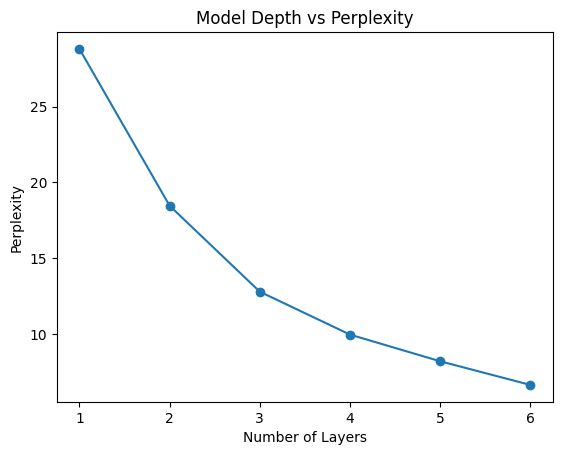

In [43]:
import matplotlib.pyplot as plt

plt.plot(layers, perplexities, marker='o')
plt.xlabel("Number of Layers")
plt.ylabel("Perplexity")
plt.title("Model Depth vs Perplexity")
plt.show()

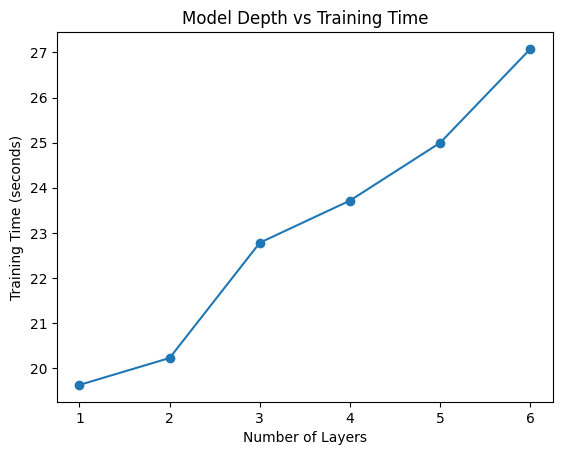

In [44]:
plt.plot(layers, times, marker='o')
plt.xlabel("Number of Layers")
plt.ylabel("Training Time (seconds)")
plt.title("Model Depth vs Training Time")
plt.show()

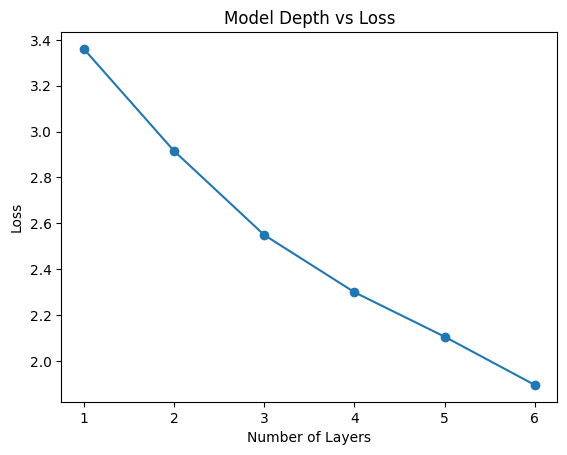

In [45]:
plt.plot(layers, losses, marker='o')
plt.xlabel("Number of Layers")
plt.ylabel("Loss")
plt.title("Model Depth vs Loss")
plt.show()

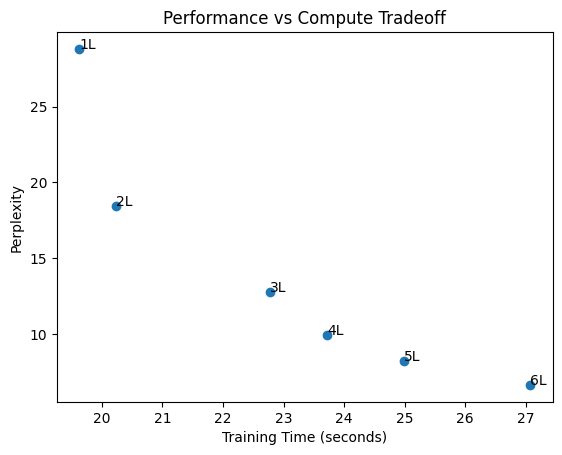

In [46]:
plt.scatter(times, perplexities)

for i, layer in enumerate(layers):
    plt.annotate(f"{layer}L", (times[i], perplexities[i]))

plt.xlabel("Training Time (seconds)")
plt.ylabel("Perplexity")
plt.title("Performance vs Compute Tradeoff")
plt.show()

In [49]:
import json

data = {
    "layers": [1,2,3,4,5,6],
    "perplexity": perplexities,
    "training_time": times
}

with open("results.json", "w") as f:
    json.dump(data, f, indent=4)

In [50]:
plt.savefig("tradeoff.png")

<Figure size 640x480 with 0 Axes>

In [51]:
!mkdir notebooks
!mkdir experiments